
Training RNN...
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


250/250 ━━━━━━━━━━━━━━━━━━━━ 43s 163ms/step - accuracy: 0.7149 - loss: 0.5366 - val_accuracy: 0.8159 - val_loss: 0.4200
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 35s 140ms/step - accuracy: 0.8388 - loss: 0.3687 - val_accuracy: 0.8420 - val_loss: 0.3802
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 40s 135ms/step - accuracy: 0.9287 - loss: 0.1892 - val_accuracy: 0.8471 - val_loss: 0.4206
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 43s 141ms/step - accuracy: 0.9793 - loss: 0.0664 - val_accuracy: 0.7901 - val_loss: 0.5938

Training LSTM...
Epoch 1/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 106s 416ms/step - accuracy: 0.8071 - loss: 0.4188 - val_accuracy: 0.8684 - val_loss: 0.3091
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 104s 417ms/step - accuracy: 0.8982 - loss: 0.2607 - val_accuracy: 0.8814 - val_loss: 0.2940
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 106s 423ms/step - accuracy: 0.9295 - loss: 0.1896 - val_accuracy: 0.8754 - val_loss: 0.3045
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 105s 419ms/step - accuracy: 0.9477 - los

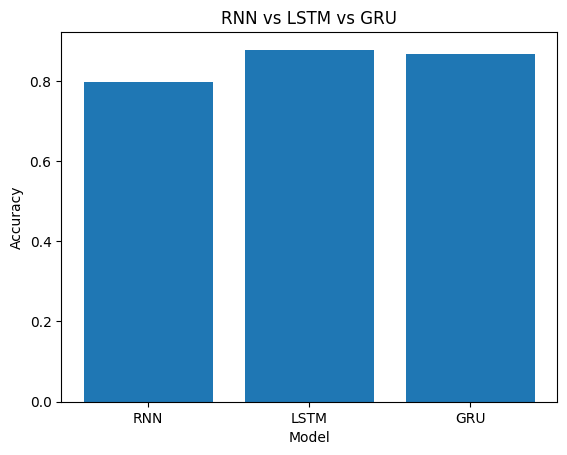

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU, Embedding
from tensorflow.keras.callbacks import EarlyStopping

# Load dataset
df = pd.read_csv('/content/IMDB Dataset.csv')

# Encode labels
df['sentiment'] = df['sentiment'].map({'positive':1, 'negative':0})

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    df['review'], df['sentiment'], test_size=0.2, random_state=42
)

# Tokenization
max_words = 10000
max_len = 200

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Padding
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

# Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=2)

# 🔹 Function to build models
def build_model(model_type):
    model = Sequential()
    model.add(Embedding(input_dim=max_words, output_dim=128, input_length=max_len))

    if model_type == 'RNN':
        model.add(SimpleRNN(64))
    elif model_type == 'LSTM':
        model.add(LSTM(64))
    elif model_type == 'GRU':
        model.add(GRU(64))

    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        loss='binary_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )

    return model

# 🔹 Train models
models = {}
histories = {}

for model_type in ['RNN', 'LSTM', 'GRU']:
    print(f"\nTraining {model_type}...")
    model = build_model(model_type)

    history = model.fit(
        X_train_pad, y_train,
        validation_split=0.2,
        epochs=5,
        batch_size=128,
        callbacks=[early_stop],
        verbose=1
    )

    models[model_type] = model
    histories[model_type] = history

# 🔹 Evaluate models
results = {}

for model_type, model in models.items():
    loss, acc = model.evaluate(X_test_pad, y_test, verbose=0)
    results[model_type] = acc
    print(f"{model_type} Accuracy: {acc:.4f}")

# 🔹 Plot comparison
plt.figure()
plt.bar(results.keys(), results.values())
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("RNN vs LSTM vs GRU")
plt.show()